In [1]:
# Add imports here
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

from sklearn.feature_extraction.text import CountVectorizer

# 1. Explore Count Vectorizer (Bag of words)
This section looks at some of the basics of count vectorizer from scikit-learn. See here for full documentation: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

- First task of NLP is to change words to numbers.

In [2]:
test_sentence = "Hopefully USU doesn't loose too badly to BYU."
another_test_sentence = "But BYU will probably choke as BYU does."
corpus = [test_sentence, another_test_sentence]

#### Basics

In [3]:
# First create vocab from corpus
clf = CountVectorizer()
clf.fit(corpus)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [4]:
clf.get_feature_names_out()

array(['as', 'badly', 'but', 'byu', 'choke', 'does', 'doesn', 'hopefully',
       'loose', 'probably', 'to', 'too', 'usu', 'will'], dtype=object)

In [5]:
clf.vocabulary_

{'hopefully': 7,
 'usu': 12,
 'doesn': 6,
 'loose': 8,
 'too': 11,
 'badly': 1,
 'to': 10,
 'byu': 3,
 'but': 2,
 'will': 13,
 'probably': 9,
 'choke': 4,
 'as': 0,
 'does': 5}

In [6]:
vectors = clf.transform(['USU'])

In [7]:
vectors

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1 stored elements and shape (1, 14)>

In [8]:
vectors.todense()

matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]])

What happens if word is out of vocab?

In [9]:
clf.transform(['Matt']).todense()

matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

#### Remove stop words

In [10]:
clf_stop = CountVectorizer(stop_words='english')  # Caution on stop words here: https://scikit-learn.org/stable/modules/feature_extraction.html#stop-words
vectors = clf_stop.fit_transform(corpus)

In [11]:
clf_stop.vocabulary_

{'hopefully': 5,
 'usu': 8,
 'doesn': 4,
 'loose': 6,
 'badly': 0,
 'byu': 1,
 'probably': 7,
 'choke': 2,
 'does': 3}

#### N-grams

In [12]:
clf_bigram = CountVectorizer(ngram_range=(1,5))  # (1,2) means unigrams and bigrams
vectors = clf_bigram.fit_transform(corpus)

In [13]:
clf_bigram.vocabulary_

{'hopefully': 27,
 'usu': 48,
 'doesn': 22,
 'loose': 32,
 'too': 44,
 'badly': 3,
 'to': 42,
 'byu': 11,
 'hopefully usu': 28,
 'usu doesn': 49,
 'doesn loose': 23,
 'loose too': 33,
 'too badly': 45,
 'badly to': 4,
 'to byu': 43,
 'hopefully usu doesn': 29,
 'usu doesn loose': 50,
 'doesn loose too': 24,
 'loose too badly': 34,
 'too badly to': 46,
 'badly to byu': 5,
 'hopefully usu doesn loose': 30,
 'usu doesn loose too': 51,
 'doesn loose too badly': 25,
 'loose too badly to': 35,
 'too badly to byu': 47,
 'hopefully usu doesn loose too': 31,
 'usu doesn loose too badly': 52,
 'doesn loose too badly to': 26,
 'loose too badly to byu': 36,
 'but': 6,
 'will': 53,
 'probably': 37,
 'choke': 17,
 'as': 0,
 'does': 21,
 'but byu': 7,
 'byu will': 13,
 'will probably': 54,
 'probably choke': 38,
 'choke as': 18,
 'as byu': 1,
 'byu does': 12,
 'but byu will': 8,
 'byu will probably': 14,
 'will probably choke': 55,
 'probably choke as': 39,
 'choke as byu': 19,
 'as byu does': 2,
 'b

#### Different analyzers

In [14]:
# 'char' will create n-grams over white spaces
clf_char = CountVectorizer(analyzer='char', ngram_range=(5,5))
clf_char.fit(corpus)
clf_char.vocabulary_

{'hopef': 32,
 'opefu': 50,
 'peful': 52,
 'efull': 28,
 'fully': 30,
 'ully ': 65,
 'lly u': 37,
 'ly us': 41,
 'y usu': 71,
 ' usu ': 10,
 'usu d': 66,
 'su do': 58,
 'u doe': 63,
 ' does': 5,
 'doesn': 25,
 "oesn'": 46,
 "esn't": 29,
 "sn't ": 57,
 "n't l": 42,
 "'t lo": 12,
 't loo': 60,
 ' loos': 6,
 'loose': 38,
 'oose ': 49,
 'ose t': 51,
 'se to': 56,
 'e too': 27,
 ' too ': 9,
 'too b': 62,
 'oo ba': 48,
 'o bad': 43,
 ' badl': 1,
 'badly': 17,
 'adly ': 14,
 'dly t': 23,
 'ly to': 40,
 'y to ': 70,
 ' to b': 8,
 'to by': 61,
 'o byu': 44,
 ' byu.': 3,
 'but b': 19,
 'ut by': 67,
 't byu': 59,
 ' byu ': 2,
 'byu w': 21,
 'yu wi': 73,
 'u wil': 64,
 ' will': 11,
 'will ': 68,
 'ill p': 33,
 'll pr': 36,
 'l pro': 35,
 ' prob': 7,
 'proba': 53,
 'robab': 54,
 'obabl': 45,
 'bably': 16,
 'ably ': 13,
 'bly c': 18,
 'ly ch': 39,
 'y cho': 69,
 ' chok': 4,
 'choke': 22,
 'hoke ': 31,
 'oke a': 47,
 'ke as': 34,
 'e as ': 26,
 ' as b': 0,
 'as by': 15,
 's byu': 55,
 'byu d': 20,
 '

In [15]:
# 'char_wb' will create n-grams over characters that are in the words
clf_char_wb = CountVectorizer(analyzer='char_wb', ngram_range=(5,5))
clf_char_wb.fit(corpus)
clf_char_wb.vocabulary_

{' hope': 7,
 'hopef': 26,
 'opefu': 32,
 'peful': 33,
 'efull': 22,
 'fully': 24,
 'ully ': 37,
 ' usu ': 12,
 ' does': 6,
 'doesn': 21,
 "oesn'": 30,
 "esn't": 23,
 "sn't ": 36,
 ' loos': 8,
 'loose': 27,
 'oose ': 31,
 ' too ': 11,
 ' badl': 1,
 'badly': 17,
 'adly ': 15,
 ' to ': 10,
 ' byu.': 4,
 'byu. ': 18,
 ' but ': 2,
 ' byu ': 3,
 ' will': 13,
 'will ': 38,
 ' prob': 9,
 'proba': 34,
 'robab': 35,
 'obabl': 28,
 'bably': 16,
 'ably ': 14,
 ' chok': 5,
 'choke': 19,
 'hoke ': 25,
 ' as ': 0,
 'does.': 20,
 'oes. ': 29}

- What are some weaknesses of the BOW model?

# 2. Build BOW Model - News Category Dataset

#### Basic EDA

Read in data

In [16]:
data = pd.read_csv("../course_creation_code/data/processed/news_category_data.csv", na_filter=False)

In [17]:
data.head(n=20)

,link,headline,category,short_description,authors,date
0,https://www.huffingtonpost.com/entry/how-trust...,How Trusting Your Gut Can Increase Wellbeing,WELLNESS,"Numerous studies, for example, have shown that...","Lissa M. Cowan, Contributor\nWriter, Teacher, ...",2013-11-27
1,https://www.huffingtonpost.com/entry/marc-chag...,Marc Chagall Birthday: Celebrating The Dreamy ...,"ARTS, CULTURE, & ENTERTAINMENT","In honor of Marc Chagall's birthday, we are re...",,2013-07-07
2,https://www.huffingtonpost.com/entry/interview...,Interview With a Meal Planner,WELLNESS,"Sure, I'm a dietitian/nutritionist and the com...","Dawn Jackson Blatner, RDN, CSSD, Contributor\n...",2014-01-09
3,https://www.huffingtonpost.com/entry/love-lett...,Love Letters: Kenai Peninsula,TRAVEL,"Alas, as it turned out I returned only for vis...","Love Letters, Contributor\nAn anthology of ref...",2013-12-18
4,https://www.huffingtonpost.com/entry/american-...,American The U.S. Holds 'Incommunicado' Wants ...,POLITICS,"""John Doe,"" a suspected ISIS fighter, has been...",Ryan J. Reilly,2018-01-05
5,https://www.huffingtonpost.com/entry/donald-tr...,Donald Trump's Supporters Love Him Even More A...,POLITICS,"“Those people come to get punched.""",Igor Bobic,2016-03-13
6,https://www.huffingtonpost.com/entry/best-part...,"The 10 Best Holiday Party Dips Of All Time, In...",FOOD & DRINK,It's holiday party season. Get your dip game i...,Rebecca Orchant,2013-12-11
7,https://www.huffingtonpost.com/entry/americas-...,"'America's Next Top Model' Fires Nigel Barker,...",STYLE & BEAUTY,"While you ponder the idea of ""Top Model"" witho...",Ellie Krupnick,2012-04-20
8,https://www.huffingtonpost.com/entry/deepak-ch...,Deepak Chopra's Quest To Find 'God 2.0',RELIGION,,Alena Hall,2014-11-11
9,https://www.huffingtonpost.com/entry/trumps-le...,Maybe Trump Should Stick To Tweeting About Hol...,POLITICS,His least popular tweets last year were all pe...,Ariel Edwards-Levy,2018-01-02


In [18]:
data.shape

(99824, 6)

In [19]:
data.columns

Index(['link', 'headline', 'category', 'short_description', 'authors', 'date'], dtype='object')

In [20]:
data.category.value_counts()

category
POLITICS                          21222
WELLNESS                          14614
ARTS, CULTURE, & ENTERTAINMENT    12580
PARENTING                          7528
STYLE & BEAUTY                     7215
TRAVEL                             5879
INTERNATIONAL NEWS                 5701
FOOD & DRINK                       3811
QUEER VOICES                       3774
SPORTS                             2972
HOME & LIVING                      2561
ENVIRONMENT                        2395
WEDDINGS                           2138
DIVORCE                            2010
RELIGION                           1537
EDUCATION                          1313
SCIENCE                            1308
TECH                               1266
Name: count, dtype: int64

In [21]:
data.headline

0             How Trusting Your Gut Can Increase Wellbeing
1        Marc Chagall Birthday: Celebrating The Dreamy ...
2                            Interview With a Meal Planner
3                            Love Letters: Kenai Peninsula
4        American The U.S. Holds 'Incommunicado' Wants ...
                               ...                        
99819           Produce You Should Never Put In The Fridge
99820    Fix Up Your Home In A Weekend With These 6 DIY...
99821    Here's Why Many Americans Are Choosing Not To ...
99822            First Uterus Transplant In The U.S. Fails
99823                           The Spirit of Philadelphia
Name: headline, Length: 99824, dtype: object

In [22]:
data.short_description

0        Numerous studies, for example, have shown that...
1        In honor of Marc Chagall's birthday, we are re...
2        Sure, I'm a dietitian/nutritionist and the com...
3        Alas, as it turned out I returned only for vis...
4        "John Doe," a suspected ISIS fighter, has been...
                               ...                        
99819    The fruits and veggies that most often get mis...
99820    Power Wash Your Walkways Spaces by Brooklyn Ge...
99821    About two-thirds of unregistered and "unlikely...
99822    The 26-year-old patient suffered sudden compli...
99823    With the Democracy Spring march launching from...
Name: short_description, Length: 99824, dtype: object

## Create count vectorizer matrix

In [23]:
news_clf = CountVectorizer(stop_words='english')
X = news_clf.fit_transform(data['headline'].values)

In [24]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 634280 stored elements and shape (99824, 41474)>

In [25]:
data.shape

(99824, 6)

In [26]:
np.nonzero(X.toarray()[0])

(array([16316, 18457, 38179, 40338]),)

In [27]:
X.toarray()[0][18457]

np.int64(1)

In [28]:
news_clf.vocabulary

In [29]:
len(news_clf.vocabulary_)

41474

In [30]:
data.head()

,link,headline,category,short_description,authors,date
0,https://www.huffingtonpost.com/entry/how-trust...,How Trusting Your Gut Can Increase Wellbeing,WELLNESS,"Numerous studies, for example, have shown that...","Lissa M. Cowan, Contributor\nWriter, Teacher, ...",2013-11-27
1,https://www.huffingtonpost.com/entry/marc-chag...,Marc Chagall Birthday: Celebrating The Dreamy ...,"ARTS, CULTURE, & ENTERTAINMENT","In honor of Marc Chagall's birthday, we are re...",,2013-07-07
2,https://www.huffingtonpost.com/entry/interview...,Interview With a Meal Planner,WELLNESS,"Sure, I'm a dietitian/nutritionist and the com...","Dawn Jackson Blatner, RDN, CSSD, Contributor\n...",2014-01-09
3,https://www.huffingtonpost.com/entry/love-lett...,Love Letters: Kenai Peninsula,TRAVEL,"Alas, as it turned out I returned only for vis...","Love Letters, Contributor\nAn anthology of ref...",2013-12-18
4,https://www.huffingtonpost.com/entry/american-...,American The U.S. Holds 'Incommunicado' Wants ...,POLITICS,"""John Doe,"" a suspected ISIS fighter, has been...",Ryan J. Reilly,2018-01-05


In [31]:
news_clf.vocabulary_

{'trusting': 38179,
 'gut': 16316,
 'increase': 18457,
 'wellbeing': 40338,
 'marc': 22583,
 'chagall': 6542,
 'birthday': 4189,
 'celebrating': 6418,
 'dreamy': 11380,
 'work': 40848,
 'expressionist': 13111,
 'great': 15978,
 'photos': 27690,
 'interview': 18975,
 'meal': 23137,
 'planner': 27982,
 'love': 21945,
 'letters': 21332,
 'kenai': 20142,
 'peninsula': 27335,
 'american': 1693,
 'holds': 17423,
 'incommunicado': 18438,
 'wants': 40021,
 'aclu': 888,
 'challenge': 6570,
 'detention': 10284,
 'donald': 11126,
 'trump': 38145,
 'supporters': 36078,
 'chicago': 6851,
 'violence': 39656,
 '10': 18,
 'best': 3949,
 'holiday': 17428,
 'party': 27010,
 'dips': 10585,
 'time': 37352,
 'order': 26190,
 'america': 1692,
 'model': 24045,
 'fires': 13908,
 'nigel': 25297,
 'barker': 3352,
 'jay': 19444,
 'manuel': 22544,
 'alexander': 1468,
 'poll': 28250,
 'deepak': 9760,
 'chopra': 6994,
 'quest': 29571,
 'god': 15639,
 'maybe': 22968,
 'stick': 35368,
 'tweeting': 38357,
 'holidays':

In [32]:
X = news_clf.transform(data['headline'].values)

In [33]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 634280 stored elements and shape (99824, 41474)>

In [34]:
data['headline'][0]

'How Trusting Your Gut Can Increase Wellbeing'

In [35]:
first_headline_vector = np.array(X.todense()[0])

In [36]:
first_headline_vector.shape

(1, 41474)

In [37]:
np.nonzero(first_headline_vector)

(array([0, 0, 0, 0]), array([16316, 18457, 38179, 40338]))

In [38]:
first_headline_vector[0,16316]

np.int64(1)

In [39]:
news_clf.vocabulary_['gut']

16316

In [40]:
for i in np.nonzero(first_headline_vector)[1]:
   print(list(news_clf.vocabulary_.keys())[list(news_clf.vocabulary_.values()).index(i)])

gut
increase
trusting
wellbeing


## Train a Logistic Regression Model
See here for other options: https://scikit-learn.org/stable/supervised_learning.html

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, data['category'], test_size=0.33, random_state=42)

In [42]:
clf = LogisticRegression(penalty=None)
clf.fit(X_train, y_train)

/Users/goodwin/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Metrics
Good overview here: https://www.evidentlyai.com/classification-metrics/multi-class-metrics

In [43]:
cm = confusion_matrix(y_test, clf.predict(X_test), labels=clf.classes_)
cm

array([[2783,   39,   22,   30,   41,   27,   53,  130,  296,   93,   28,
          23,   64,  197,   15,   82,   39,  228],
       [  40,  438,    1,    1,    5,    2,    4,   44,   18,    4,    3,
           0,    3,   13,    2,    6,   24,   54],
       [  18,    1,  165,    2,    3,    2,   10,   43,   93,    4,    6,
           1,    9,    9,    5,    6,    3,   59],
       [  30,    4,    4,  362,   19,   11,   56,   38,  125,    7,    5,
          21,    4,   12,    5,   32,    5,   72],
       [  40,    2,    4,   11,  845,   38,    9,   38,   25,    6,    3,
           3,    5,   21,    2,   60,    2,  145],
       [  45,    3,    3,   18,   23,  517,    8,   20,   16,    3,    1,
           2,    1,   58,    3,   39,    3,   51],
       [  59,    4,    7,   33,    4,    4, 1162,   24,  311,   13,   27,
          13,   20,    7,   11,   68,    7,   73],
       [ 129,   40,   40,   13,   24,   33,   13, 1569,   74,   43,   12,
           9,   19,   55,    8,   51,   15,  336],


In [44]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

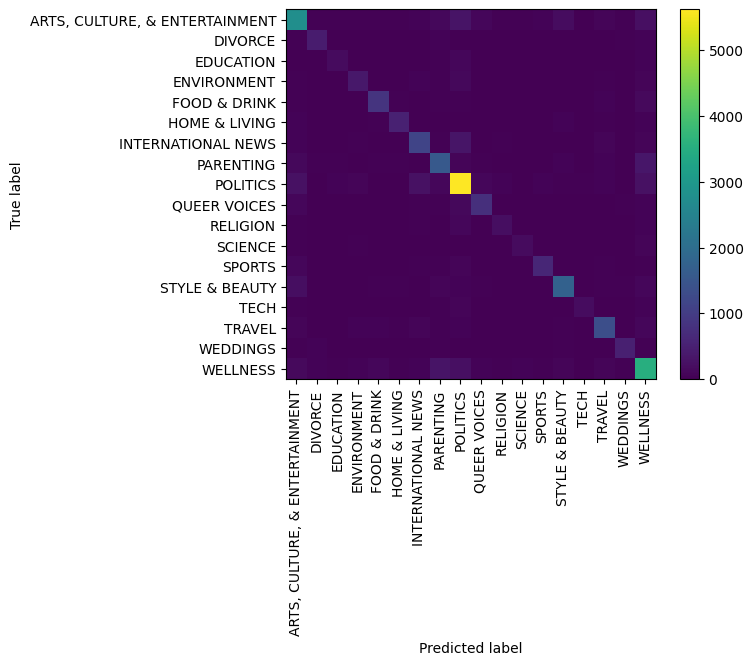

In [45]:
disp.plot(include_values=False, xticks_rotation = 'vertical')
plt.show()

In [45]:
row_sums = cm.sum(axis=1, keepdims=True)

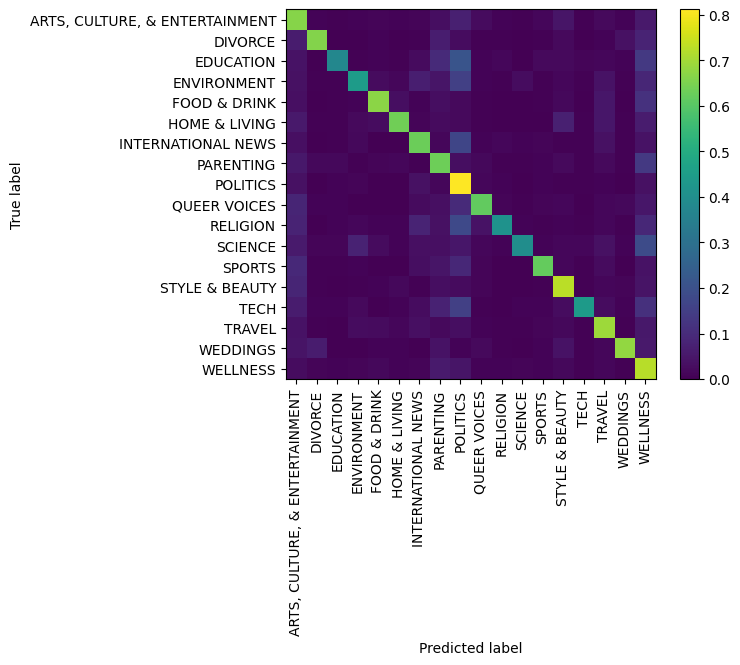

In [46]:
# Politics is higher because there are so many political news stories, but there are some interesting correlations
disp = ConfusionMatrixDisplay(confusion_matrix=cm / row_sums, display_labels=clf.classes_)
disp.plot(include_values=False, xticks_rotation = 'vertical')
plt.show()

In [46]:
print(classification_report(y_test, clf.predict(X_test)))

                                precision    recall  f1-score   support

ARTS, CULTURE, & ENTERTAINMENT       0.68      0.66      0.67      4190
                       DIVORCE       0.64      0.66      0.65       662
                     EDUCATION       0.44      0.38      0.41       439
                   ENVIRONMENT       0.50      0.45      0.47       812
                  FOOD & DRINK       0.73      0.67      0.70      1259
                 HOME & LIVING       0.67      0.64      0.65       814
            INTERNATIONAL NEWS       0.63      0.63      0.63      1847
                     PARENTING       0.61      0.63      0.62      2483
                      POLITICS       0.77      0.81      0.79      6925
                  QUEER VOICES       0.65      0.62      0.63      1215
                      RELIGION       0.52      0.41      0.46       529
                       SCIENCE       0.49      0.40      0.44       436
                        SPORTS       0.69      0.62      0.66  

#### Micro Precision, Micro recall
Same as accuracy. Is this good or bad? Should we use Micro or Macro?

In [47]:
precision_score(y_test, clf.predict(X_test), average='micro')

0.6829882824357962